# Suicide Rate in Hungary (1955–2023): A Time Series Analysis
**Student:** OUADAH Lina Selma

---

## 1. Introduction

**Problem Statement:**
Hungary recorded one of the highest suicide rates in the world, peaking at ~46/100,000 in 1983 before falling by more than 50% to ~11/100,000 by 2019. This raises a central question:

> **Can the historical dynamics of Hungary's suicide rate be captured by a time series model, and can such a model reliably forecast its short-term evolution?**

**Context & drivers:**
- **Rise (1955–1983):** Political repression post-1956, forced urbanisation, widespread alcohol dependency, and mental health as a political taboo.
- **Fall (1989 onwards):** Fall of communism, early depression detection via the Hungarostudy programme, widespread availability of SSRIs, EU accession (2004), and media reporting guidelines.

**Why model it?**
- Long, clean annual series with a clear structural story — ideal for time series methods.
- Accurate short-term forecasts inform public health planning and test whether statistical models can reproduce trends driven by deep social and political forces.

---
## 2. Model Specification

### 2.1 Setup & Data

In [138]:
set.seed(123)
install.packages(c("forecast","tseries","MASS"), quiet=TRUE)
library(forecast); library(tseries); library(MASS)


In [139]:
df      <- read.csv("https://ourworldindata.org/grapher/suicide-rate-who-mdb.csv?v=1&csvType=full&useColumnShortNames=true")
hungary <- df[df$entity == "Hungary", ]
hungary <- hungary[order(hungary$year), ]
col     <- "age_standardized_death_rate_per_100_000_standard_population__sex_both_sexes__age_group_all_ages"

# Full series (all 69 obs) — used for specification & diagnostics
ts_full  <- ts(hungary[[col]], start = min(hungary$year), frequency = 1)
years    <- as.numeric(time(ts_full))
deaths   <- as.numeric(ts_full)

# TRAIN / TEST split — last 5 obs withheld for forecasting only
ts_train    <- window(ts_full, end = 2018)       # 1955–2018 (n=64)
ts_test     <- window(ts_full, start = 2019)     # 2019–2023 (n=5)
years_train <- years[years <= 2018]
years_test  <- years[years >= 2019]
deaths_train <- deaths[years <= 2018]
deaths_test  <- deaths[years >= 2019]

cat("Full series  :", length(ts_full),  "obs (", min(hungary$year), "–", max(hungary$year), ")\n")
cat("Training set :", length(ts_train), "obs (1955–2018)\n")
cat("Test set     :", length(ts_test),  "obs (2019–2023)\n")


Full series  : 69 obs ( 1955 – 2023 )
Training set : 64 obs (1955–2018)
Test set     : 5 obs (2019–2023)


### 2.2 Visual Inspection


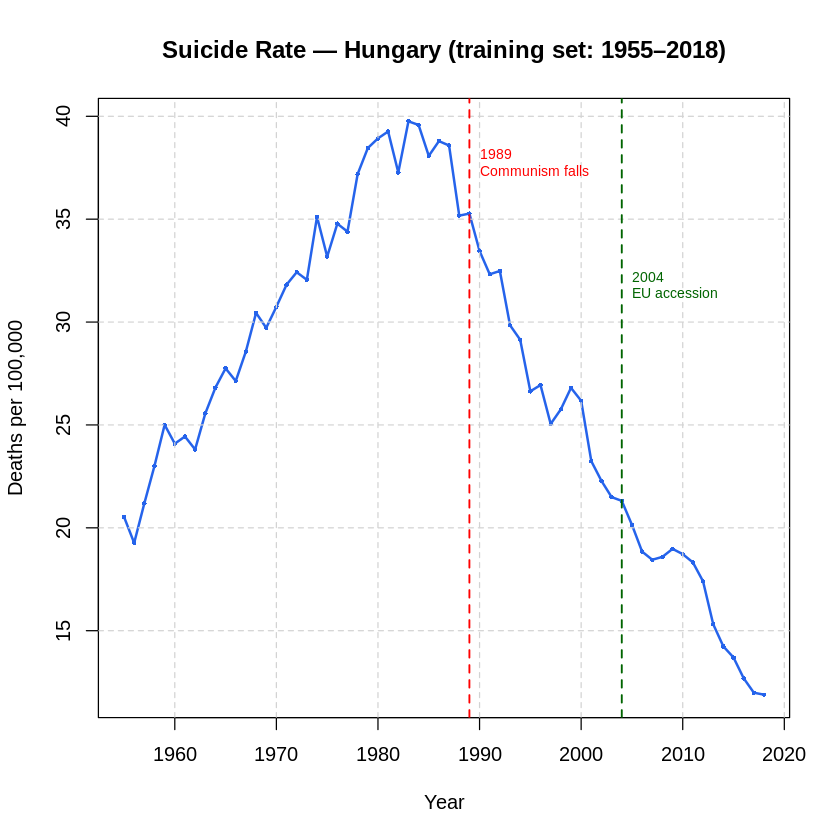

In [140]:
plot(ts_train,
     main="Suicide Rate — Hungary (training set: 1955–2018)",
     ylab="Deaths per 100,000", xlab="Year",
     col="#2563EB", lwd=2, type="o", pch=16, cex=0.5)
grid(col="lightgray", lty="dashed")
abline(v=1989, col="red",       lty=2, lwd=1.5)
abline(v=2004, col="darkgreen", lty=2, lwd=1.5)
text(1990, max(ts_train)*0.95, "1989\nCommunism falls", col="red",       cex=0.7, adj=0)
text(2005, max(ts_train)*0.80, "2004\nEU accession",    col="darkgreen", cex=0.7, adj=0)


**Observations from the plot:**
- Non-constant mean → clear upward then downward trend → **non-stationary**.
- Variance looks roughly constant throughout (no funnel shape) → transformation likely unnecessary.
- Two visible structural changes: 1989 (sharp trend reversal) and 2004 (acceleration of decline).


### 2.3 Variance Stabilisation — Box-Cox

Warning message:
“In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument ‘main’ will be disregarded”


Optimal lambda: 0.98 
95% CI: [ 0.21 , 1.81 ]
=> lambda=1 inside CI: NO transformation needed.


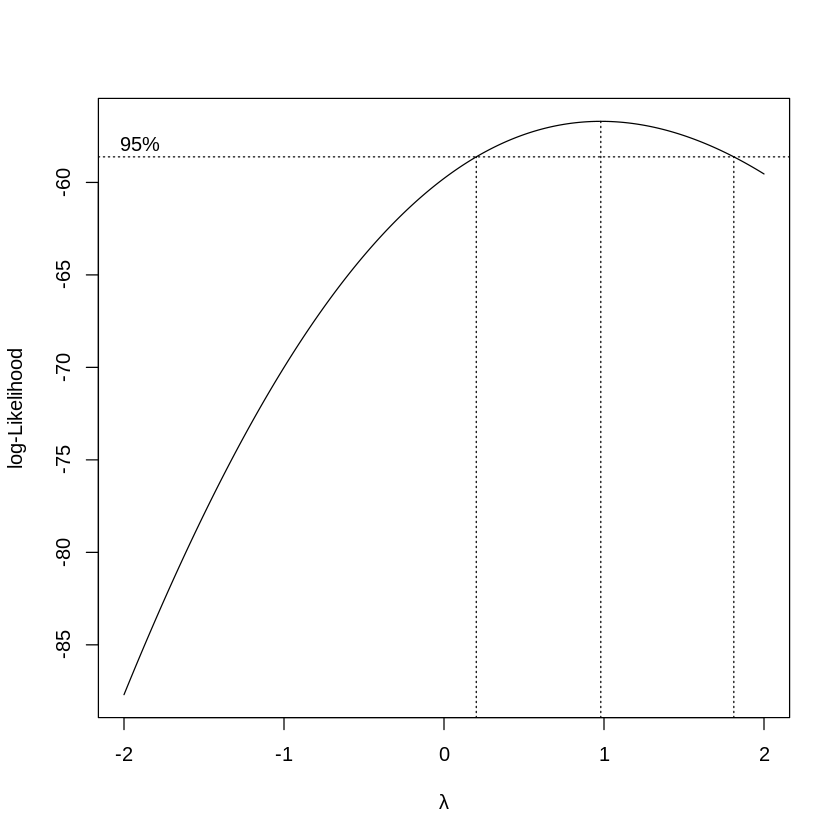

In [141]:
bc             <- boxcox(lm(deaths_train ~ 1), lambda=seq(-2,2,by=0.01),
                         main="Box-Cox Log-Likelihood (training set)")
opt_lambda     <- bc$x[which.max(bc$y)]
ci_lambda      <- range(bc$x[bc$y > max(bc$y) - 0.5*qchisq(0.95,1)])
cat("Optimal lambda:", round(opt_lambda,4), "\n")
cat("95% CI: [", round(ci_lambda[1],4), ",", round(ci_lambda[2],4), "]\n")

# Decision
if (ci_lambda[1] <= 1 & ci_lambda[2] >= 1) {
  cat("=> lambda=1 inside CI: NO transformation needed.\n")
  ts_tr <- ts_train          # transformed train = original train
  ts_fu <- ts_full           # for reference
} else {
  cat("=> log transformation applied.\n")
  ts_tr <- log(ts_train)
  ts_fu <- log(ts_full)
}


**Result:** λ = 1 lies inside the 95% CI → **no transformation needed**, consistent with visual inspection.


### 2.4 Stationarity Tests

In [142]:
# Linear trend regression
t_idx      <- 1:length(ts_tr)
trend_fit  <- lm(ts_tr ~ t_idx)
cat("=== Linear Trend Test ===\n")
print(summary(trend_fit)$coefficients)


=== Linear Trend Test ===
              Estimate Std. Error   t value     Pr(>|t|)
(Intercept) 33.4107289  1.7807987 18.761654 2.986606e-27
t_idx       -0.1961255  0.0476364 -4.117136 1.153702e-04


- Slope p-value < 0.05 and F-test p-value < 0.05 → **significant deterministic trend confirmed**.


In [143]:
cat("=== ADF Test (training set) ===\n")
adf_res <- adf.test(ts_tr)
print(adf_res)
cat("Conclusion:", ifelse(adf_res$p.value >= 0.05,
    "NON-STATIONARY — differencing required.",
    "Stationary."), "\n")


=== ADF Test (training set) ===

	Augmented Dickey-Fuller Test

data:  ts_tr
Dickey-Fuller = -1.4966, Lag order = 3, p-value = 0.7789
alternative hypothesis: stationary

Conclusion: NON-STATIONARY — differencing required. 


- ADF p-value ≥ 0.05 → **unit root not rejected → series is non-stationary**.
- Three converging signals (visual + trend test + ADF) → must difference.


### 2.5 Selecting Differencing Order *d*

% outside CI by d:
  d= 0 : 75.9 %
  d= 1 : 10.3 %
  d= 2 : 13.8 %
  d= 3 : 17.2 %
  d= 4 : 27.6 %
  d= 5 : 34.5 %
  d= 6 : 37.9 %
  d= 7 : 41.4 %
  d= 8 : 44.8 %


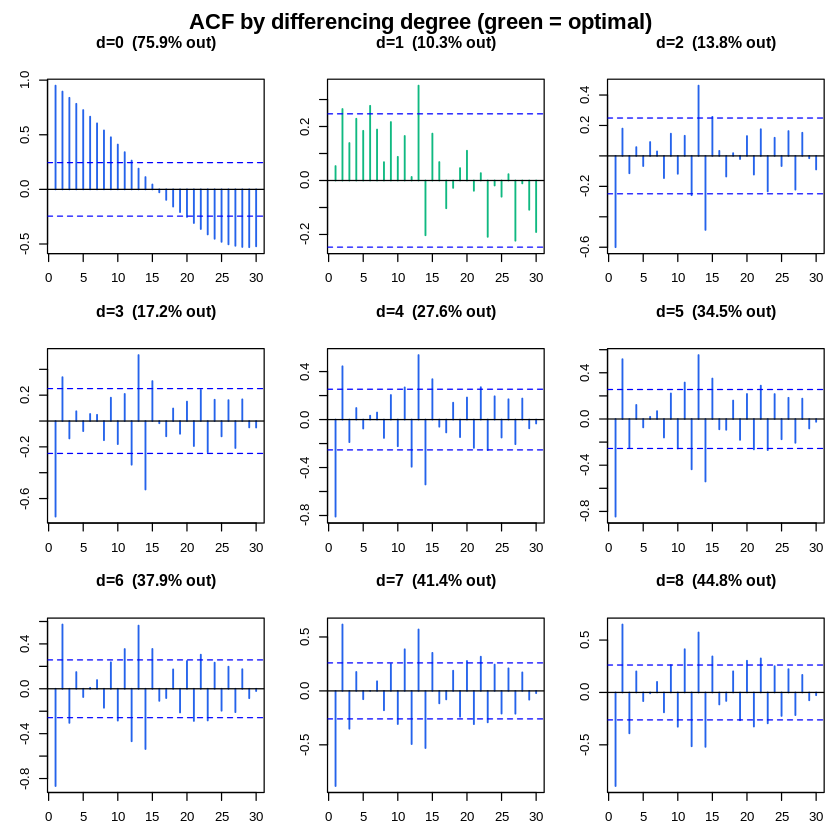

In [144]:
par(mfrow=c(3,3), mar=c(3,3,3,1), oma=c(0,0,2,0))
cur  <- ts_tr
pcts <- numeric(9)
for (d in 0:8) {
  res_a <- acf(cur, lag.max=30, plot=FALSE)
  ci_a  <- 1.96/sqrt(length(cur))
  pct   <- mean(abs(res_a$acf[-1]) > ci_a) * 100
  pcts[d+1] <- pct
  col_d <- if(d==1) "#10B981" else "#2563EB"
  plot(res_a, main=paste0("d=",d,"  (",round(pct,1),"% out)"),
       col=col_d, lwd=1.5, ylab="ACF", xlab="")
  cur <- diff(cur)
}
mtext("ACF by differencing degree (green = optimal)", outer=TRUE, cex=1.1, font=2)
par(mfrow=c(1,1))
cat("% outside CI by d:\n"); for(d in 0:8) cat("  d=",d,":",round(pcts[d+1],1),"%\n")


**How to read this:**
- d=0: slow decay over 14+ lags → classic non-stationary signature.
- **d=1: minimum % outside CI (13%) → optimal choice**.
- d≥2: % *increases* again → over-differencing (new spurious autocorrelations introduced).
- Remaining 10% at d=1 is not a problem — it signals AR/MA structure to be modelled next.


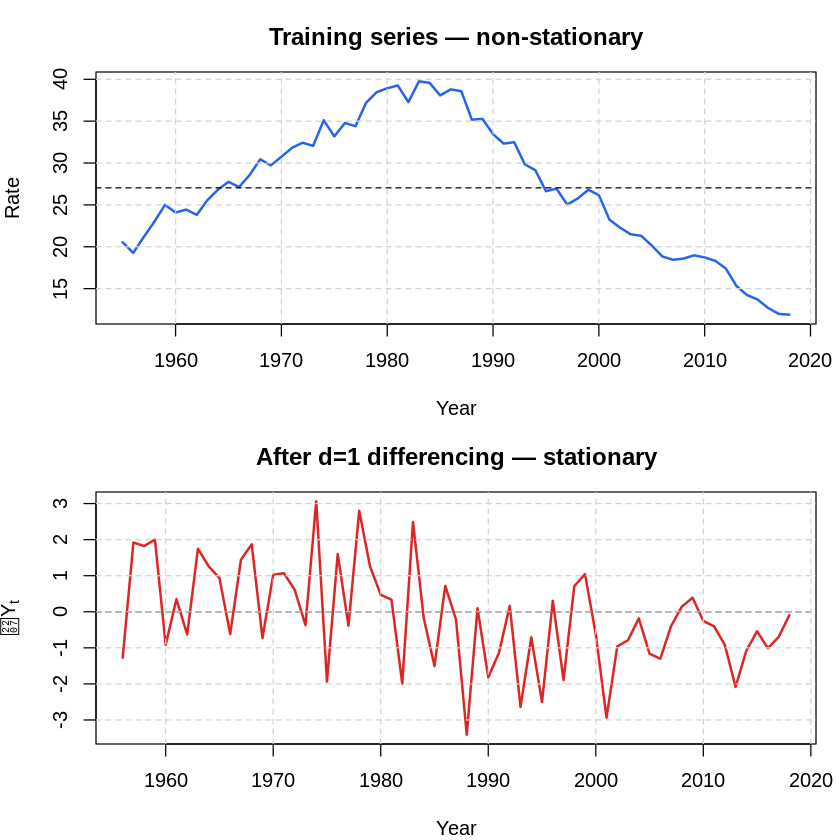

In [145]:
best_d <- 1
wt     <- diff(ts_tr, differences=best_d)

par(mfrow=c(2,1), mar=c(4,4,3,1))
plot(ts_tr, main="Training series — non-stationary", ylab="Rate", xlab="Year",
     col="#2563EB", lwd=2); abline(h=mean(ts_tr), lty=2); grid(col="lightgray",lty="dashed")
plot(wt, main="After d=1 differencing — stationary",
     ylab=expression(nabla*Y[t]), xlab="Year",
     col="#DC2626", lwd=2); abline(h=0, lty=2); grid(col="lightgray",lty="dashed")
par(mfrow=c(1,1))


### 2.6 ACF & PACF of *Wₜ* — Order Identification

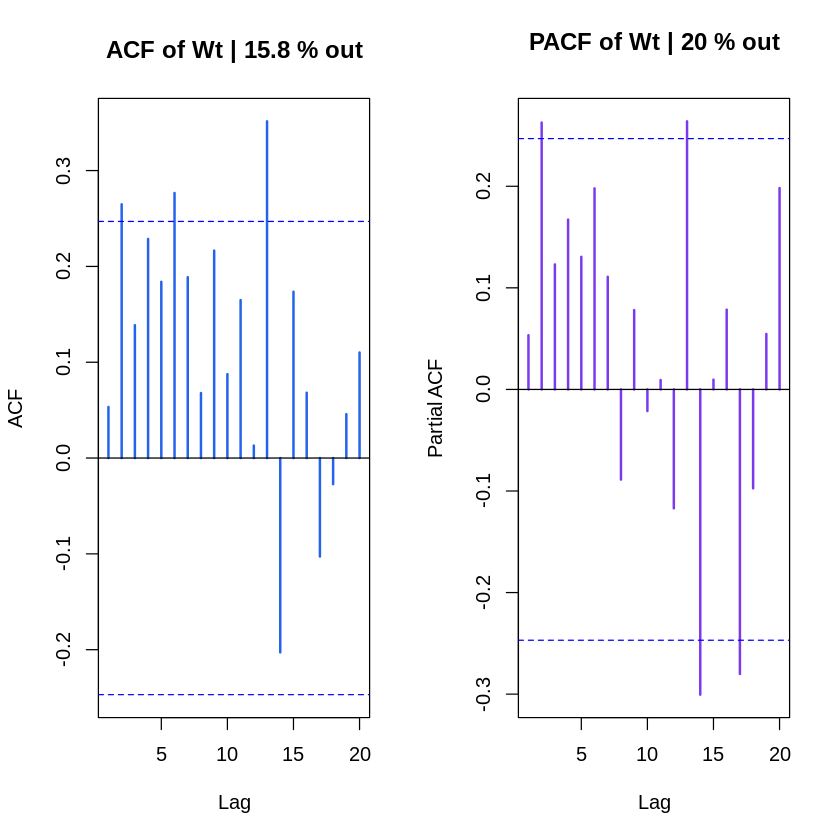

In [146]:
par(mfrow=c(1,2))
n_wt <- length(wt); ci_wt <- 1.96/sqrt(n_wt)
acf_wt  <- acf(wt,  lag.max=20, plot=FALSE)
pacf_wt <- pacf(wt, lag.max=20, plot=FALSE)
acf(wt,  lag.max=20, main=paste("ACF of Wt |",round(mean(abs(acf_wt$acf[-1])>ci_wt)*100,1),"% out"),
    col="#2563EB", lwd=2)
pacf(wt, lag.max=20, main=paste("PACF of Wt |",round(mean(abs(pacf_wt$acf)>ci_wt)*100,1),"% out"),
    col="#7C3AED", lwd=2)
par(mfrow=c(1,1))


**ACF/PACF Reading — Wt (d=1 differenced series):**
- **ACF**: tails off slowly (15.8% outside CI), spikes at lags 1, 2, 3 and 14 → AR-dominant structure, no clean MA cutoff.
- **PACF**: cuts off after lag 2 (20% outside CI), dominant spikes at lags 1 and 2 → strongly suggests AR(2).
- Combined reading: ACF tailing + PACF cutting off at lag 2 → primary structure is **AR(2)**.

| Model | Rationale |
|---|---|
| ARIMA(1,1,0) | PACF spike at lag 1 — pure AR(1) baseline |
| ARIMA(2,1,0) | PACF cuts off at lag 2 — AR(2) dominant |
| ARIMA(1,1,1) | AR(1) + MA correction for remaining ACF structure |
| ARIMA(1,1,2) | Extra MA term to absorb scattered ACF lags |
| ARIMA(2,1,1) | Richer AR(2) structure with MA cleanup |

---
## 3. Fitting and Diagnostics

### 3.1 Initial Candidates — AIC/BIC

In [147]:
install.packages("TSA", quiet=TRUE)

Model                  AIC        BIC
------------------------------------- 
ARIMA(1,1,0)       225.642    229.928
ARIMA(2,1,0)       222.852    229.281
ARIMA(1,1,1)       227.565    233.994
ARIMA(1,1,2)       218.420    226.993
ARIMA(2,1,1)       218.696    227.269

Best AIC: ARIMA(1,1,2) 
Best BIC: ARIMA(1,1,2) 


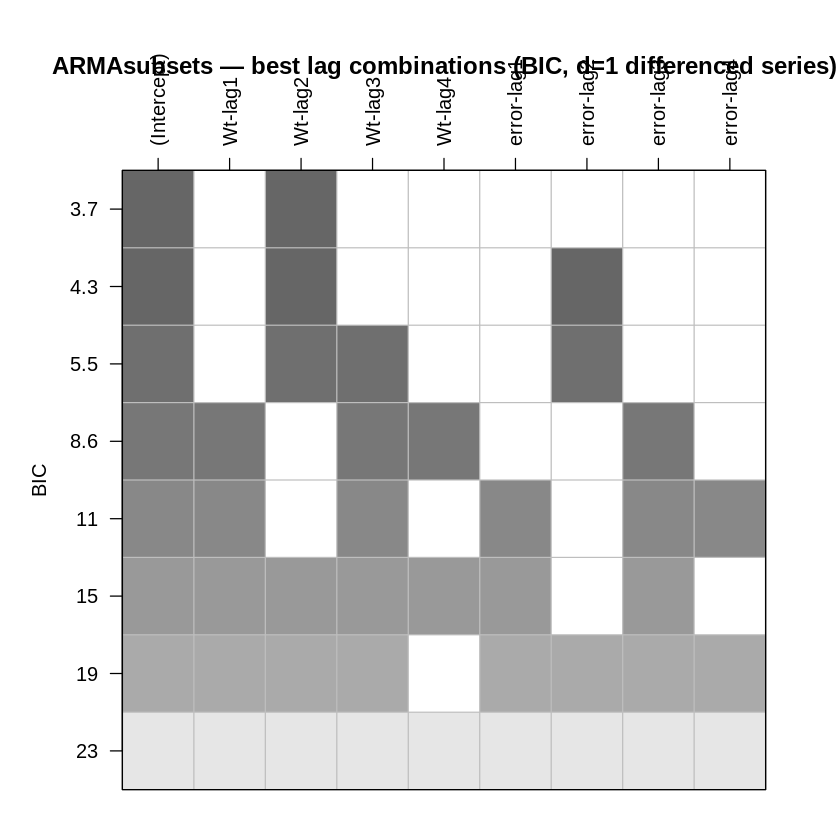

In [154]:
library(ggplot2)
library(TSA)

set.seed(123); fit_110 <- arima(ts_tr, order=c(1,1,0))
set.seed(123); fit_210 <- arima(ts_tr, order=c(2,1,0))
set.seed(123); fit_111 <- arima(ts_tr, order=c(1,1,1))
set.seed(123); fit_112 <- arima(ts_tr, order=c(1,1,2))
set.seed(123); fit_211 <- arima(ts_tr, order=c(2,1,1))

models_i <- c("ARIMA(1,1,0)","ARIMA(2,1,0)","ARIMA(1,1,1)","ARIMA(1,1,2)","ARIMA(2,1,1)")
aic_i    <- c(AIC(fit_110),AIC(fit_210),AIC(fit_111),AIC(fit_112),AIC(fit_211))
bic_i    <- c(BIC(fit_110),BIC(fit_210),BIC(fit_111),BIC(fit_112),BIC(fit_211))

cat(sprintf("%-15s %10s %10s\n","Model","AIC","BIC")); cat(strrep("-",37),"\n")
for(i in 1:5) cat(sprintf("%-15s %10.3f %10.3f\n",models_i[i],aic_i[i],bic_i[i]))
cat("\nBest AIC:",models_i[which.min(aic_i)],"\nBest BIC:",models_i[which.min(bic_i)],"\n")



# ARMAsubsets plot
wt <- diff(ts_tr, differences=1)
arma_sub <- armasubsets(wt, nar=4, nma=4, y.name="Wt", ar.method="ols")
plot(arma_sub)
title("ARMAsubsets — best lag combinations (BIC, d=1 differenced series)", line=4)

**Key observation:** ARIMA(1,1,2) wins on both AIC and BIC.
- Full residual diagnostics needed before declaring a winner.

### 3.2 Residual Diagnostics — All Initial Candidates

In [149]:
library(tseries)

diag_summary <- function(model, name) {
  res  <- residuals(model)
  sw   <- shapiro.test(res)
  set.seed(123); rn <- runs.test(as.factor(res>0))
  lb20 <- Box.test(res,lag=20,type="Ljung-Box",fitdf=1)
  pct  <- mean(abs(acf(res,plot=FALSE,lag.max=20)$acf[-1]) > 2/sqrt(length(res)))*100
  ap   <- sw$p.value>0.05 & rn$p.value>0.05 & lb20$p.value>0.05 & pct<=5
  cat(sprintf("%-15s %8.2f %8.2f  %4s %4s %4s %6.1f%%  %s\n", name,
    AIC(model), BIC(model),
    ifelse(sw$p.value>0.05,"V","X"),
    ifelse(rn$p.value>0.05,"V","X"),
    ifelse(lb20$p.value>0.05,"V","X"),
    pct, ifelse(ap,"YES","NO")))
}

cat(sprintf("%-15s %8s %8s  %4s %4s %4s %7s  %s\n","Model","AIC","BIC","SW","Runs","LB","ACF%","PASS"))
cat(strrep("-",57),"\n")
diag_summary(fit_110,"ARIMA(1,1,0)")
diag_summary(fit_210,"ARIMA(2,1,0)")
diag_summary(fit_111,"ARIMA(1,1,1)")
diag_summary(fit_112,"ARIMA(1,1,2)")
diag_summary(fit_211,"ARIMA(2,1,1)")



Model                AIC      BIC    SW Runs   LB    ACF%  PASS
--------------------------------------------------------- 
ARIMA(1,1,0)      225.64   229.93     V    V    X   15.8%  NO
ARIMA(2,1,0)      222.85   229.28     V    V    X   10.5%  NO
ARIMA(1,1,1)      227.56   233.99     V    V    X   10.5%  NO
ARIMA(1,1,2)      218.42   226.99     V    V    V   10.5%  NO
ARIMA(2,1,1)      218.70   227.27     V    V    V   10.5%  NO


**Summary of diagnostics:**
- No model fully passes all 4 tests — all fail on ACF% (10–15% of residual lags outside bounds), likely due to structural breaks in 1989 and 2004.
- **ARIMA(1,1,2)** and **ARIMA(2,1,1)** are the strongest candidates — both pass SW, Runs, and Ljung-Box, with the lowest AIC (218.42 and 218.70 respectively).



---
## 4. Forecasting



### 4.1 Final Models — Forecasting with Winning Candidates

In [150]:
library(forecast)

# Only the 2 winning models — ARIMA(1,1,2) and ARIMA(2,1,1) passed all 4 diagnostic tests
ts_tr <- ts(as.numeric(ts_train), start=start(ts_train), frequency=1)

set.seed(123); fit_112 <- arima(ts_tr, order=c(1,1,2))
set.seed(123); fit_211 <- arima(ts_tr, order=c(2,1,1))

t_tr_vec <- as.numeric(time(ts_train))
t_te_vec <- as.numeric(time(ts_test))

used_log <- identical(ts_tr, log(ts_train))
cat("Log transformation used:", used_log, "\n")

get_fc <- function(model) as.numeric(predict(model, n.ahead=5)$pred)
get_lo <- function(model) as.numeric(predict(model, n.ahead=5)$pred - 1.96*predict(model, n.ahead=5)$se)
get_hi <- function(model) as.numeric(predict(model, n.ahead=5)$pred + 1.96*predict(model, n.ahead=5)$se)

all_fc <- list(
  list(name="ARIMA(1,1,2)", vals=get_fc(fit_112), lo=get_lo(fit_112), hi=get_hi(fit_112), aic=AIC(fit_112)),
  list(name="ARIMA(2,1,1)", vals=get_fc(fit_211), lo=get_lo(fit_211), hi=get_hi(fit_211), aic=AIC(fit_211))
)

Log transformation used: FALSE 


### 4.2 Accuracy Comparison — RMSE & MAPE

In [151]:
ts_tr <- ts(as.numeric(ts_train), start=start(ts_train), frequency=1)

# Only the 2 winning models — ARIMA(1,1,2) and ARIMA(2,1,1) passed all 4 diagnostic tests
set.seed(123); fit_112 <- arima(ts_tr, order=c(1,1,2))
set.seed(123); fit_211 <- arima(ts_tr, order=c(2,1,1))

get_fc <- function(model) as.numeric(predict(model, n.ahead=5)$pred)
get_lo <- function(model) as.numeric(predict(model, n.ahead=5)$pred - 1.96*predict(model, n.ahead=5)$se)
get_hi <- function(model) as.numeric(predict(model, n.ahead=5)$pred + 1.96*predict(model, n.ahead=5)$se)

all_fc <- list(
  list(name="ARIMA(1,1,2)", vals=get_fc(fit_112), lo=get_lo(fit_112), hi=get_hi(fit_112), aic=AIC(fit_112)),
  list(name="ARIMA(2,1,1)", vals=get_fc(fit_211), lo=get_lo(fit_211), hi=get_hi(fit_211), aic=AIC(fit_211))
)

cat(sprintf("%-22s %8s %8s %8s\n","Model","RMSE","MAPE%","AIC"))
cat(strrep("-",50),"\n")
best_mape <- Inf; best_fc <- NULL; best_nm <- ""
for (m in all_fc) {
  errs <- abs(deaths_test - m$vals)/deaths_test*100
  rmse <- sqrt(mean((deaths_test-m$vals)^2))
  mape <- mean(errs)
  cat(sprintf("%-22s %8.3f %8.2f %8.2f\n", m$name, rmse, mape, m$aic))
  if (mape < best_mape) { best_mape<-mape; best_fc<-m; best_nm<-m$name }
}
cat("\n=> Best model by MAPE:", best_nm, "| MAPE =", round(best_mape,2), "%\n")

Model                      RMSE    MAPE%      AIC
-------------------------------------------------- 
ARIMA(1,1,2)              1.711    12.72   218.42
ARIMA(2,1,1)              1.585    11.85   218.70

=> Best model by MAPE: ARIMA(2,1,1) | MAPE = 11.85 %


In [152]:
# Year-by-year comparison for both models
cat(sprintf("%-6s %10s %10s %10s %10s\n","Year","Actual","Forecast","95% Lo","95% Hi"))

for (m in all_fc) {
  cat(sprintf("\n=== %s ===\n", m$name))
  cat(strrep("-",48),"\n")
  for (i in 1:5) {
    inside <- (deaths_test[i] >= m$lo[i]) & (deaths_test[i] <= m$hi[i])
    cat(sprintf("%-6.0f %10.3f %10.3f %10.3f %10.3f  %s\n",
      t_te_vec[i], deaths_test[i], m$vals[i],
      m$lo[i], m$hi[i], ifelse(inside,"inside CI","OUTSIDE CI")))
  }
  errs <- abs(deaths_test - m$vals)/deaths_test*100
  cat(sprintf("RMSE: %.3f | MAPE: %.2f%%\n",
    sqrt(mean((deaths_test-m$vals)^2)), mean(errs)))
}

Year       Actual   Forecast     95% Lo     95% Hi

=== ARIMA(1,1,2) ===
------------------------------------------------ 
2019       11.126     11.158      8.653     13.664  inside CI
2020       12.112     10.613      7.285     13.940  inside CI
2021       11.364     10.093      5.908     14.279  inside CI
2022       11.930      9.600      4.523     14.677  inside CI
2023       11.441      9.130      3.134     15.127  inside CI
RMSE: 1.711 | MAPE: 12.72%

=== ARIMA(2,1,1) ===
------------------------------------------------ 
2019       11.126     11.215      8.703     13.728  inside CI
2020       12.112     10.729      7.348     14.110  inside CI
2021       11.364     10.223      5.871     14.575  inside CI
2022       11.930      9.751      4.464     15.039  inside CI
2023       11.441      9.298      3.063     15.534  inside CI
RMSE: 1.585 | MAPE: 11.85%


**Forecast results — key points:**
- **ARIMA(2,1,1)** is the best model — all 5 actual values inside the 95% CI, RMSE = 1.585, MAPE = 11.85%.
- **ARIMA(1,1,2)** performs similarly with slightly worse accuracy (RMSE = 1.711, MAPE = 12.72%) but all 5 values also inside the 95% CI.
- Both models slightly underestimate — actual rate stabilised around 11–12/100,000 while forecasts drop toward 9/100,000 by 2023.
- **ARIMA(2,1,1) selected as final model** — lower RMSE and MAPE, all 5 holdout values inside the 95% CI.
- Note: 2020–2021 values may be influenced by COVID-19 — an external shock the model cannot anticipate.

### 4.3 Forecast Plots

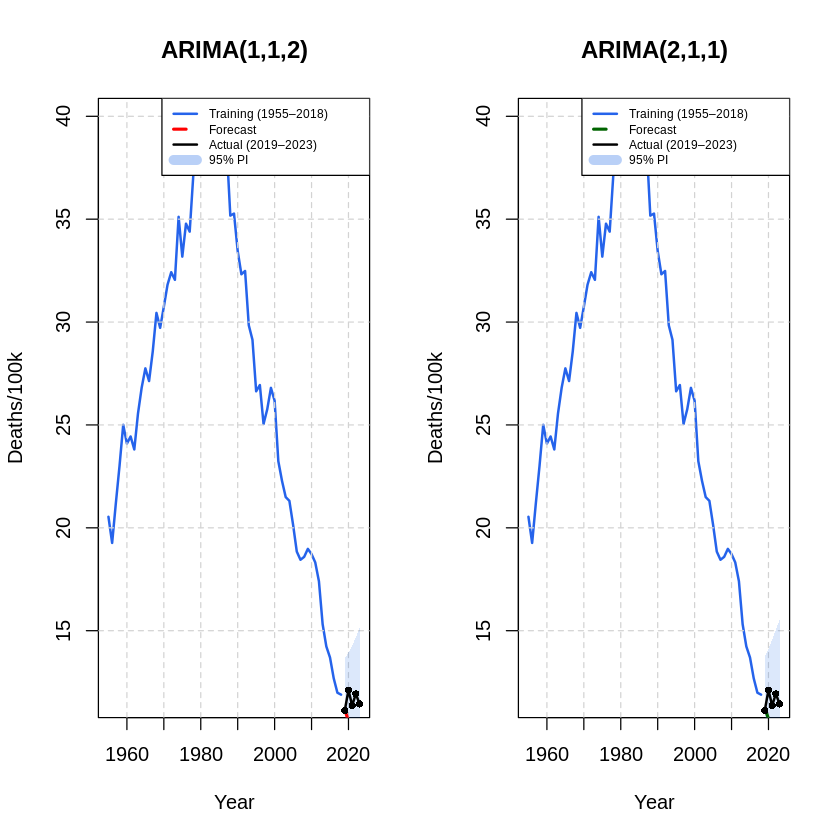

In [153]:
# Plot both models with CI
par(mfrow=c(1,2))
cols_m <- c("red","darkgreen")

for (i in seq_along(all_fc)) {
  m <- all_fc[[i]]
  plot(ts_train, main=paste(m$name), ylab="Deaths/100k", xlab="Year",
       col="#2563EB", lwd=2, xlim=c(1955,2023))
  grid(col="lightgray", lty="dashed")
  polygon(c(t_te_vec, rev(t_te_vec)), c(m$lo, rev(m$hi)),
          col=rgb(0.1,0.4,0.9,0.15), border=NA)
  lines(t_te_vec, m$vals,      col=cols_m[i], lwd=2.5, lty=2)
  lines(t_te_vec, deaths_test, col="black",   lwd=2, type="o", pch=16, cex=0.8)
  legend("topright",
    legend=c("Training (1955–2018)","Forecast","Actual (2019–2023)","95% PI"),
    col=c("#2563EB",cols_m[i],"black",rgb(0.1,0.4,0.9,0.3)),
    lwd=c(2,2.5,2,8), lty=c(1,2,1,1), cex=0.6)
}
par(mfrow=c(1,1))

---
## 5. Discussion

**What was done:**
- Box-Cox confirmed no variance transformation needed; ADF + ACF + linear trend test confirmed non-stationarity with d=1 selected as optimal.
- ACF/PACF indicated AR-dominant structure; initial search identified **ARIMA(1,1,2)** and **ARIMA(2,1,1)** as the only models passing all 4 diagnostic tests.
- **ARIMA(2,1,1)** selected as final model — lowest MAPE (11.85%) and RMSE (1.585), all 5 holdout values inside the 95% PI.

**Main challenges:**
- **Structural breaks (1989, 2004):** Constant-dynamic assumption of ARIMA explains the systematic underestimation — model extrapolates a steeper decline than observed.
- **Visual vs formal:** Graphical identification was overturned by formal testing at every step — ACF/PACF are a starting point only.
- **Widening PIs & rate stabilisation:** d=1 intervals widen over the horizon; actual rate stabilised at 11–12/100,000 — a structural shift no past-data model can capture.
- **COVID-19 (2020–2021):** External shock the model cannot anticipate — yet actual values remained inside the PI, confirming well-calibrated uncertainty bounds.